# Yield Prediction – Linear & Polynomial Regression

**Goal:** Predict the `yield` of a crop given pollination-related features using linear and polynomial regression models.  
**Evaluation metric:** Mean Absolute Error (MAE) — lower is better.

### Notebook structure
1. Load & inspect data  
2. Exploratory Data Analysis (EDA)  
3. Data preparation (missing values, feature engineering, scaling)  
4. Model 1 – Linear Regression (degree 1 baseline)  
5. Model 2 – Polynomial Regression degree 2 (plain)  
6. Model 3 – Polynomial Regression degree 2 + Ridge regularisation  
7. Model comparison & selection  
8. Generate test predictions & save submission

## 1. Load & Inspect Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

train = pd.read_csv("C:\\Users\\Lenovo\\Desktop\\Zindua Python\\Machine Leaarning Foundations\\0205-linear-regression-project-ogwaanto\\train.csv")
test  = pd.read_csv("C:\\Users\\Lenovo\\Desktop\\Zindua Python\\Machine Leaarning Foundations\\0205-linear-regression-project-ogwaanto\\test.csv")
sample_sub = pd.read_csv("C:\\Users\\Lenovo\\Desktop\\Zindua Python\\Machine Leaarning Foundations\\0205-linear-regression-project-ogwaanto\\sample_submission.csv")

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()

ModuleNotFoundError: No module named 'matplotlib'

 Loading all files upfront lets us confirm column alignment between train and test before any transformations.

In [5]:
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 15289 entries, 0 to 15288
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15289 non-null  int64  
 1   clonesize             15289 non-null  float64
 2   honeybee              15289 non-null  float64
 3   bumbles               15289 non-null  float64
 4   andrena               15289 non-null  float64
 5   osmia                 15289 non-null  float64
 6   MaxOfUpperTRange      15289 non-null  float64
 7   MinOfUpperTRange      15289 non-null  float64
 8   AverageOfUpperTRange  15289 non-null  float64
 9   MaxOfLowerTRange      15289 non-null  float64
 10  MinOfLowerTRange      15289 non-null  float64
 11  AverageOfLowerTRange  15289 non-null  float64
 12  RainingDays           15289 non-null  float64
 13  AverageRainingDays    15289 non-null  float64
 14  fruitset              15289 non-null  float64
 15  fruitmass             15289 no

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
count,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000
mean,7644.000000,19.704690,0.389314,0.286768,0.492675,0.592355,82.169887,49.673281,68.656256,59.229538,28.660553,48.568500,18.660865,0.324176,0.502741,0.446553,36.164950,6025.193999
std,4413.698468,6.595211,0.361643,0.059917,0.148115,0.139489,9.146703,5.546405,7.641807,6.610640,3.195367,5.390545,11.657582,0.163905,0.074390,0.037035,4.031087,1337.056850
min,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,69.700000,39.000000,58.200000,50.200000,24.300000,41.200000,1.000000,0.060000,0.192732,0.311921,22.079199,1945.530610
25%,3822.000000,12.500000,0.250000,0.250000,0.380000,0.500000,77.400000,46.800000,64.700000,55.800000,27.000000,45.800000,16.000000,0.260000,0.458246,0.419216,33.232449,5128.163510
50%,7644.000000,25.000000,0.500000,0.250000,0.500000,0.630000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,16.000000,0.260000,0.506600,0.446570,36.040675,6117.475900
75%,11466.000000,25.000000,0.500000,0.380000,0.630000,0.750000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,24.000000,0.390000,0.560445,0.474134,39.158238,7019.694380
max,15288.000000,40.000000,18.430000,0.585000,0.750000,0.750000,94.600000,57.200000,79.000000,68.200000,33.000000,55.900000,34.000000,0.560000,0.652144,0.535660,46.585105,8969.401840


All 16 feature columns are numeric (`float64`). The `id` column is a row index with no predictive value and will be dropped. No categorical encoding is needed.

## 2. Exploratory Data Analysis

In [6]:
#  Missing value check 
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()
print('Missing in train:', missing_train[missing_train > 0].to_dict() or 'None')
print('Missing in test :', missing_test[missing_test   > 0].to_dict() or 'None')

Missing in train: None
Missing in test : None


Missing value checks come first. If missings were present, imputation (e.g. median fill) would need to be fitted on training data only and then applied to test, omitting this step would cause data leakage. Here the dataset is complete, so no imputation is required.

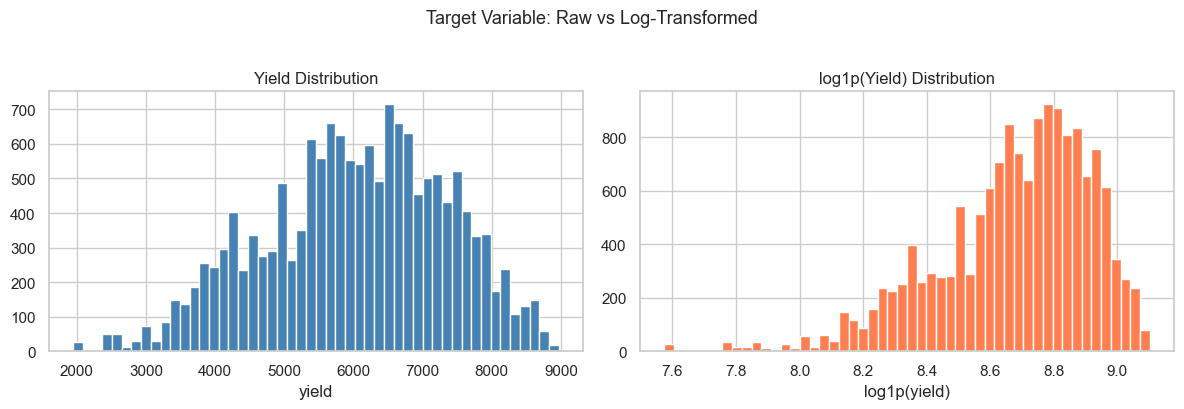

Skewness (raw)   : -0.291
Skewness (log1p) : -0.932


In [7]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['yield'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Yield Distribution')
axes[0].set_xlabel('yield')

np.log1p(train['yield']).hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('log1p(Yield) Distribution')
axes[1].set_xlabel('log1p(yield)')

plt.suptitle('Target Variable: Raw vs Log-Transformed', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Skewness (raw)   : {train["yield"].skew():.3f}')
print(f'Skewness (log1p) : {np.log1p(train["yield"]).skew():.3f}')

Linear regression assumes roughly symmetric residuals. If `yield` is heavily skewed, a log transformation can improve linearity and reduce MAE. The skewness scores above guide this decision low skewness (< |0.5|) means we can model `yield` directly without a log transform.

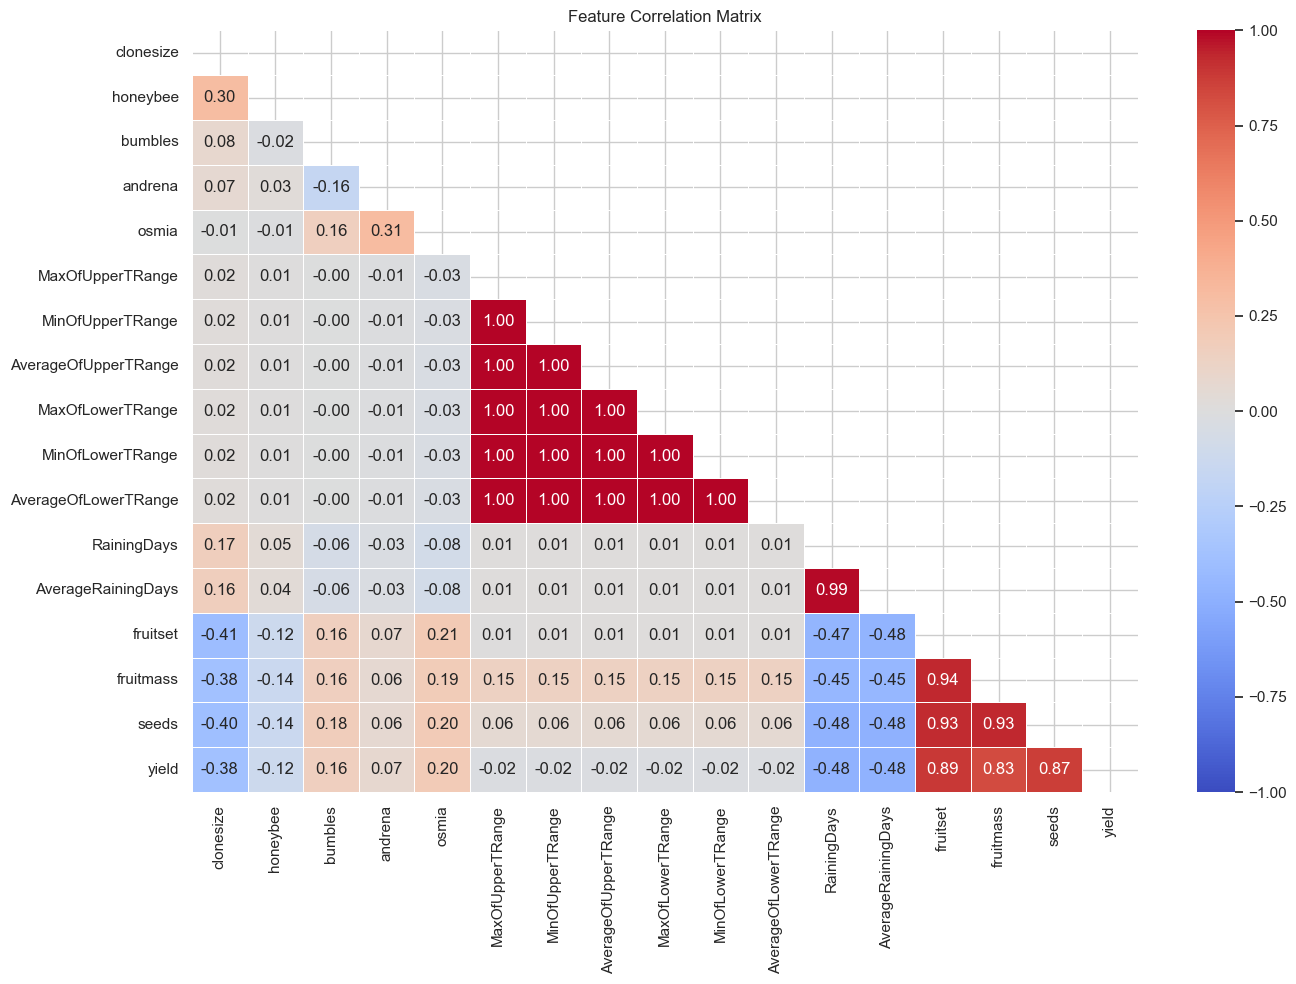


Correlation with yield (sorted):
fruitset                0.885967
seeds                   0.868853
fruitmass               0.826481
osmia                   0.198264
bumbles                 0.161145
andrena                 0.073969
MinOfUpperTRange       -0.021929
AverageOfUpperTRange   -0.021940
AverageOfLowerTRange   -0.022081
MaxOfLowerTRange       -0.022197
MinOfLowerTRange       -0.022319
MaxOfUpperTRange       -0.022517
honeybee               -0.118001
clonesize              -0.382619
RainingDays            -0.477191
AverageRainingDays     -0.483870
Name: yield, dtype: float64


In [8]:
#  Correlation heatmap
feature_cols = [c for c in train.columns if c not in ('id', 'yield')]
corr = train[feature_cols + ['yield']].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nCorrelation with yield (sorted):')
print(corr['yield'].drop('yield').sort_values(ascending=False))

 The correlation heatmap serves two purposes for linear modelling:  
1. **Feature relevance** features with |r| close to 1 with `yield` are strong linear predictors.  
2. **Multicollinearity** high correlations *between features* inflate coefficient variance in plain Linear Regression, motivating Ridge regularisation in the polynomial model.

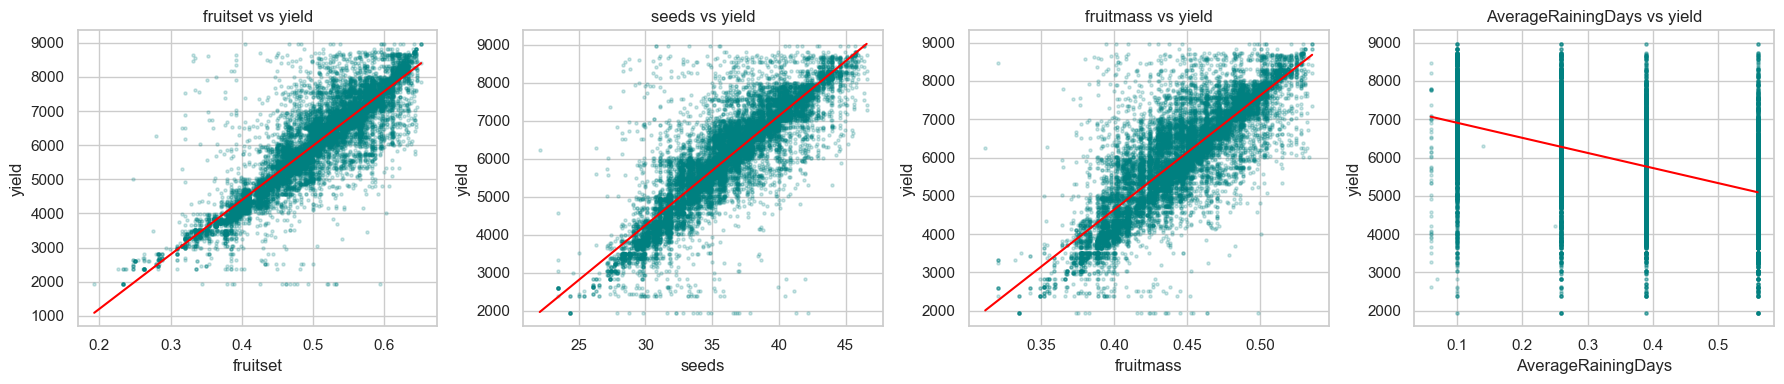

In [9]:
# --- Scatter plots: top 4 features vs yield ---
top4 = corr['yield'].drop('yield').abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, top4):
    ax.scatter(train[feat], train['yield'], alpha=0.2, s=5, color='teal')
    m, b = np.polyfit(train[feat], train['yield'], 1)
    xs = np.linspace(train[feat].min(), train[feat].max(), 100)
    ax.plot(xs, m*xs + b, color='red', linewidth=1.5)
    ax.set_xlabel(feat); ax.set_ylabel('yield')
    ax.set_title(f'{feat} vs yield')
plt.tight_layout()
plt.show()

Scatter plots with linear trend lines visually confirm whether the feature-yield relationships are linear. Curved patterns suggest polynomial terms (degree 2) would better capture the true signal.

## 3. Data Preparation

In [10]:
# a. Separate features and target; drop id 
X      = train[feature_cols].copy()
y      = train['yield'].copy()
X_test = test[feature_cols].copy()

print('Feature matrix shape (train):', X.shape)
print('Feature matrix shape (test) :', X_test.shape)

Feature matrix shape (train): (15289, 16)
Feature matrix shape (test) : (10194, 16)


Dropping `id` prevents the model learning a spurious pattern from row indices. Using `feature_cols` to select from both train and test guarantees identical column ordering

In [11]:
# b. Feature Engineering
# Applied identically to train and test
for df in [X, X_test]:
    # Total pollinator abundance
    df['total_bees']       = df['honeybee'] + df['bumbles'] + df['andrena'] + df['osmia']
    # Temperature variability (range)
    df['upper_temp_range'] = df['MaxOfUpperTRange'] - df['MinOfUpperTRange']
    df['lower_temp_range'] = df['MaxOfLowerTRange'] - df['MinOfLowerTRange']
    # Interaction: fruitset x fruitmass
    df['fruitset_x_mass']  = df['fruitset'] * df['fruitmass']

print('Feature matrix shape after engineering:', X.shape)
print('New features:', ['total_bees', 'upper_temp_range', 'lower_temp_range', 'fruitset_x_mass'])

Feature matrix shape after engineering: (15289, 20)
New features: ['total_bees', 'upper_temp_range', 'lower_temp_range', 'fruitset_x_mass']



- **`total_bees`** pollinators collectively drive fruit set; summing them reduces noise and compresses four correlated columns into one signal.  
- **`upper_temp_range` / `lower_temp_range`** temperature *variability* (max − min) is often a better plant stress indicator than absolute temperature.  
- **`fruitset_x_mass`** a manually added interaction term: high yield needs *both* many fruits setting *and* each fruit to be heavy. Linear models cannot discover interactions on their own; this term makes it explicit.

These are arithmetic transformations applied identically to both splits. No fitting required, so there is zero risk of data leakage.

In [12]:
# c. Train / Validation Split
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f'Train split : {X_tr.shape[0]} rows')
print(f'Val split   : {X_val.shape[0]} rows')

Train split : 12231 rows
Val split   : 3058 rows


A held-out validation set (20 %) lets us inspect residuals and compute a quick MAE without running the full cross-validation loop. Cross-validation is still used for final model selection.

In [14]:
# 3d. Scaling
# Scaler is fitted ONLY on training data to prevent leakage
scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

print('Scaling complete.')
print('Feature means after scaling (first 5):', X_tr_s[:, :5].mean(axis=0).round(4))

Scaling complete.
Feature means after scaling (first 5): [-0.  0.  0.  0.  0.]


**Rationale:** `StandardScaler` centres each feature to mean 0 and scales to unit variance. This is essential for linear models because:  
- Polynomial features like $x^2$ can be orders of magnitude larger than $x$; scaling puts all terms on a comparable scale.  
- Ridge regularisation penalises all coefficients equally.

In the cross-validation cells below  `Pipeline` objects are used so the scaler is always re-fitted on each training fold, not on the full dataset.

## 4. Model 1 – Linear Regression (Degree 1 Baseline)

In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

lr_cv = -cross_val_score(lr_pipeline, X, y, cv=kf,
                          scoring='neg_mean_absolute_error', n_jobs=-1)
print(f'Linear Regression  CV MAE : {lr_cv.mean():.2f} ± {lr_cv.std():.2f}')

# Fit on train split for residual inspection
lr_pipeline.fit(X_tr, y_tr)
y_val_lr = lr_pipeline.predict(X_val)
print(f'                   Val MAE: {mean_absolute_error(y_val, y_val_lr):.2f}')

Linear Regression  CV MAE : 373.40 ± 8.74
                   Val MAE: 371.00


Enclosing scaler + model in a `Pipeline` ensures scaling parameters are computed on each fold's training portion only — preventing data leakage during cross-validation.

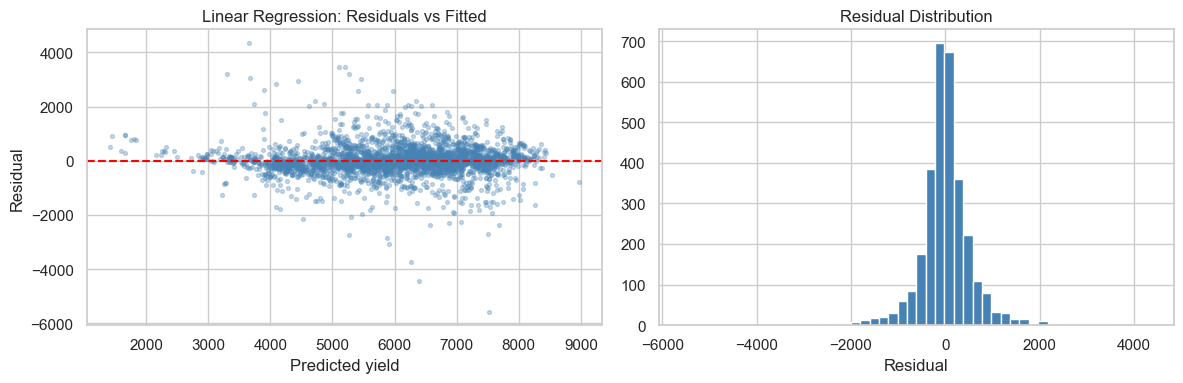

Top 10 coefficients (by magnitude):
MinOfLowerTRange        2343.195599
AverageOfUpperTRange   -2107.250776
AverageOfLowerTRange   -1428.163568
fruitset                1317.296093
MaxOfLowerTRange         934.344550
fruitset_x_mass         -778.572327
seeds                    579.748231
lower_temp_range        -383.596921
MinOfUpperTRange         282.070513
MaxOfUpperTRange         215.327431
dtype: float64


In [ ]:
# Residual analysis
residuals_lr = y_val - y_val_lr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_val_lr, residuals_lr, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted yield'); axes[0].set_ylabel('Residual')
axes[0].set_title('Linear Regression: Residuals vs Fitted')
axes[1].hist(residuals_lr, bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

coef_lr = pd.Series(lr_pipeline.named_steps['model'].coef_,
                    index=X.columns).sort_values(key=abs, ascending=False)

print(coef_lr.head(10))

The residuals-vs-fitted plot diagnoses whether the linear assumption holds. A random horizontal scatter around zero is ideal. Curved patterns (e.g., a U-shape) suggest the model is systematically under- or over-predicting at certain yield levels, which a polynomial model could correct. Coefficient magnitudes confirm which features the model leaned on most after scaling.

## 5. Model 2 – Polynomial Regression (Degree 2, No Regularisation)

In [17]:
poly2_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

# Show feature expansion
n_original = X.shape[1]
n_poly     = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X).shape[1]
print(f'Features: {n_original} (original) → {n_poly} (after degree-2 expansion)')

poly2_cv = -cross_val_score(poly2_pipeline, X, y, cv=kf,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
print(f'Poly deg-2 (no reg)  CV MAE : {poly2_cv.mean():.2f} ± {poly2_cv.std():.2f}')

poly2_pipeline.fit(X_tr, y_tr)
y_val_poly2 = poly2_pipeline.predict(X_val)
print(f'                     Val MAE: {mean_absolute_error(y_val, y_val_poly2):.2f}')

Features: 20 (original) → 230 (after degree-2 expansion)
Poly deg-2 (no reg)  CV MAE : 377.55 ± 15.61
                     Val MAE: 371.67


 
Degree 2 is preferred over degree 3 because degree 3 expands ~20 features to nearly 1 000, which massively overfits without very strong regularisation. With unregularised OLS and ~150 features vs 15 000 samples the ratio is still manageable, but we expect some overfitting, motivating Model 3.

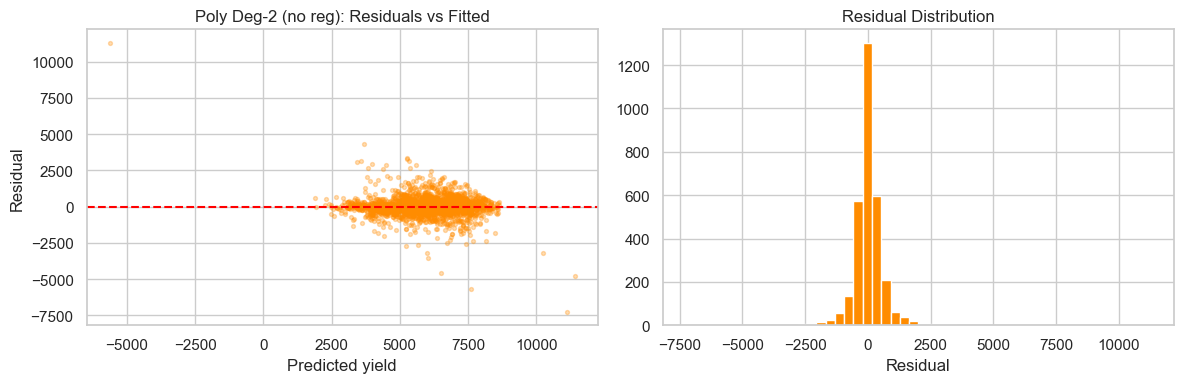

In [18]:
# Residual analysis
residuals_poly2 = y_val - y_val_poly2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_val_poly2, residuals_poly2, alpha=0.3, s=8, color='darkorange')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted yield'); axes[0].set_ylabel('Residual')
axes[0].set_title('Poly Deg-2 (no reg): Residuals vs Fitted')
axes[1].hist(residuals_poly2, bins=50, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

Comparing these residuals to Model 1 reveals whether the quadratic expansion helped or overfitted. A higher CV MAE or wider, more erratic spread signals overfitting due to the large unregularised coefficient space. This motivates adding Ridge in Model 3.

## 6. Model 3 – Polynomial Regression (Degree 2) + Ridge Regularisation

In [19]:
poly_ridge_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Ridge())
])

param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

grid_search = GridSearchCV(
    poly_ridge_pipeline, param_grid,
    cv=kf, scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=0
)
grid_search.fit(X, y)

best_alpha   = grid_search.best_params_['model__alpha']
best_cv_mae  = -grid_search.best_score_
print(f'Best alpha  : {best_alpha}')
print(f'Best CV MAE : {best_cv_mae:.2f}')

cv_results = pd.DataFrame({
    'alpha'   : param_grid['model__alpha'],
    'mean_MAE': -grid_search.cv_results_['mean_test_score'],
    'std_MAE' :  grid_search.cv_results_['std_test_score']
})
print('\nAll alpha results:')
print(cv_results.to_string(index=False))

Best alpha  : 1
Best CV MAE : 367.95

All alpha results:
  alpha   mean_MAE   std_MAE
   0.01 371.732811 11.303172
   0.10 368.869360  8.794331
   1.00 367.947221  7.715026
  10.00 369.559372  7.901391
  50.00 370.249472  8.262310
 100.00 370.571025  8.322756
 500.00 374.265095  7.955107
1000.00 377.858833  7.936095


This shrinks all coefficients towards zero without eliminating any feature, ideal when the polynomial expansion produces many correlated terms. The hyperparameter **α** controls the trade-off:
- α → 0: reduces to plain OLS (may overfit with ~150 features)  
- α → ∞: all coefficients → 0 (underfits)  

`GridSearchCV` searches over a log-spaced grid, using the same 5-fold CV splits as Models 1 and 2 so comparisons are fair. `Pipeline` ensures scaling is re-fitted inside every fold.

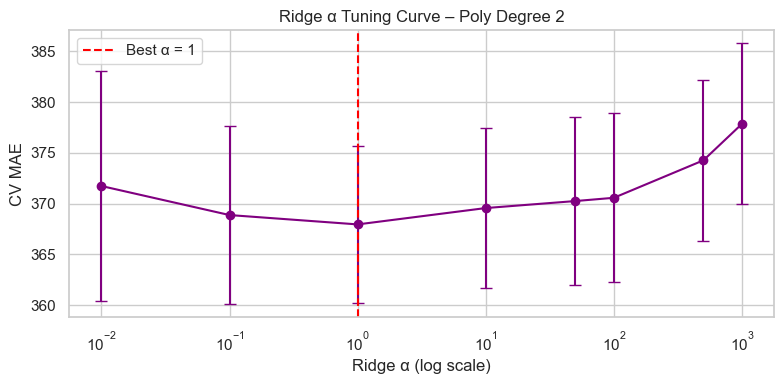

In [20]:
# Alpha tuning curve
plt.figure(figsize=(8, 4))
plt.errorbar(cv_results['alpha'], cv_results['mean_MAE'],
             yerr=cv_results['std_MAE'], marker='o', color='purple',
             capsize=4, linewidth=1.5)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α = {best_alpha}')
plt.xscale('log')
plt.xlabel('Ridge α (log scale)'); plt.ylabel('CV MAE')
plt.title('Ridge α Tuning Curve – Poly Degree 2')
plt.legend()
plt.tight_layout()
plt.show()

The tuning curve illustrates the bias-variance trade-off. The U-shape (or descent-then-plateau) shows:
- **Left side** (low α): insufficient regularisation → overfitting → higher CV MAE  
- **Right side** (high α): too much shrinkage → underfitting → higher CV MAE  
- **Minimum**: optimal balance between bias and variance for this dataset

Poly deg-2 + Ridge(α=1)  Val MAE: 364.83


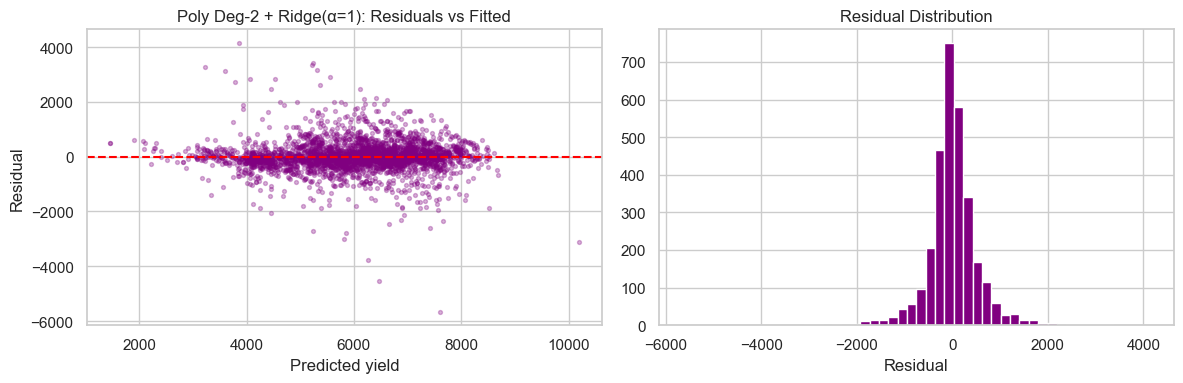

In [21]:
# Fit best Ridge model on train split for held-out residual inspection
best_ridge_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=best_alpha))
])
best_ridge_pipe.fit(X_tr, y_tr)
y_val_ridge = best_ridge_pipe.predict(X_val)

print(f'Poly deg-2 + Ridge(α={best_alpha})  Val MAE: {mean_absolute_error(y_val, y_val_ridge):.2f}')

residuals_ridge = y_val - y_val_ridge
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_val_ridge, residuals_ridge, alpha=0.3, s=8, color='purple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted yield'); axes[0].set_ylabel('Residual')
axes[0].set_title(f'Poly Deg-2 + Ridge(α={best_alpha}): Residuals vs Fitted')
axes[1].hist(residuals_ridge, bins=50, color='purple', edgecolor='white')
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

After tuning, recheck the residuals. A tighter, more symmetric distribution compared to the unregularised polynomial model confirms that Ridge has successfully reduced overfitting while retaining the expressive power of the degree-2 expansion.

## 7. Model Comparison & Selection

                        Model  CV MAE (mean)  CV MAE (std)
     Poly deg=2 + Ridge (α=1)     367.947221      7.715026
    Linear Regression (deg=1)     373.401423      8.741774
Polynomial Regression (deg=2)     377.546763     15.606614


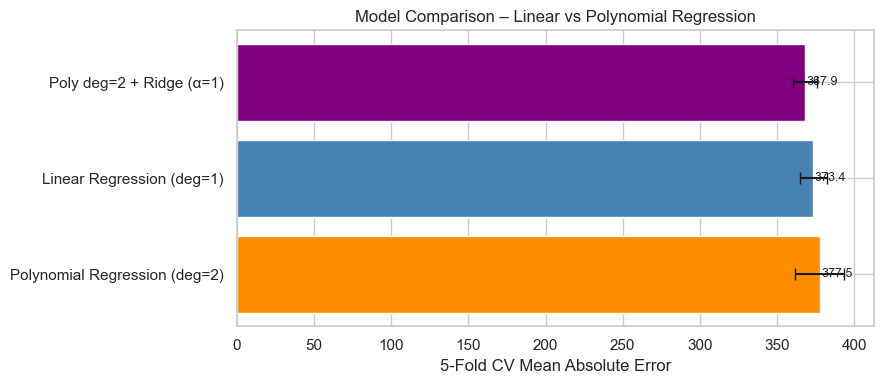


Best model: Poly deg=2 + Ridge (α=1)  (CV MAE = 367.95)


In [22]:
# Recompute ridge CV score with best alpha for clean comparison table
ridge_cv = -cross_val_score(
    Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)),
              ('scaler', StandardScaler()),
              ('model', Ridge(alpha=best_alpha))]),
    X, y, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1
)

comparison = pd.DataFrame([
    {'Model': 'Linear Regression (deg=1)',
     'CV MAE (mean)': lr_cv.mean(),    'CV MAE (std)': lr_cv.std()},
    {'Model': 'Polynomial Regression (deg=2)',
     'CV MAE (mean)': poly2_cv.mean(), 'CV MAE (std)': poly2_cv.std()},
    {'Model': f'Poly deg=2 + Ridge (α={best_alpha})',
     'CV MAE (mean)': ridge_cv.mean(), 'CV MAE (std)': ridge_cv.std()},
]).sort_values('CV MAE (mean)')

print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colours = ['steelblue', 'darkorange', 'purple']
# Sort colours to match sorted df
model_colour = {'Linear Regression (deg=1)': 'steelblue',
                'Polynomial Regression (deg=2)': 'darkorange',
                f'Poly deg=2 + Ridge (α={best_alpha})': 'purple'}
bar_colours = [model_colour[m] for m in comparison['Model']]
bars = ax.barh(comparison['Model'], comparison['CV MAE (mean)'],
               xerr=comparison['CV MAE (std)'], color=bar_colours,
               edgecolor='white', capsize=4)
ax.set_xlabel('5-Fold CV Mean Absolute Error')
ax.set_title('Model Comparison – Linear vs Polynomial Regression')
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

best_name = comparison.iloc[0]['Model']
print(f'\nBest model: {best_name}  (CV MAE = {comparison.iloc[0]["CV MAE (mean)"]:.2f})')

The error bars show fold-to-fold variance: a model with lower mean MAE and lower variance is strictly preferable, it is both more accurate and more stable across different data subsets.

## 8. Generate Test Predictions

In [25]:
# GridSearchCV with refit=True (default) already refitted the best model on full X
final_model = grid_search.best_estimator_

y_pred = final_model.predict(X_test)

submission = pd.DataFrame({'id': test['id'], 'yield': y_pred})
submission.to_csv('submission.csv', index=False)

submission.head(10)

,id,yield
0,15289,4269.376146
1,15290,6239.807532
2,15291,7179.041895
3,15292,4903.060296
4,15293,3877.634170
5,15294,5109.371298
6,15295,7196.045047
7,15296,6515.315432
8,15297,8095.699097
9,15298,4193.214554


`GridSearchCV` with `refit=True` automatically retrains the best estimator on the entire training dataset after the search completes. This means predictions use all ~15 000 training rows rather than 4/5 from a single fold, maximising the information available to the final model.

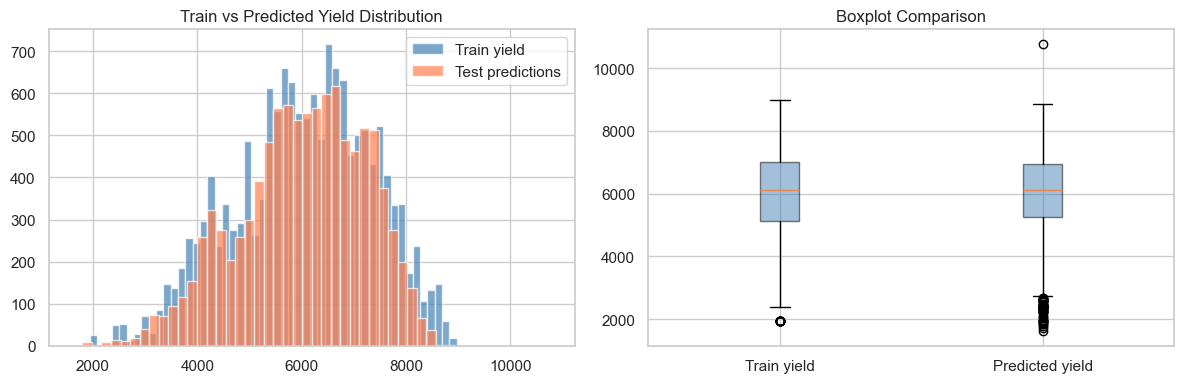

Train yield     — mean: 6025.2, std: 1337.1
Predicted yield — mean: 6009.4, std: 1216.7


In [ ]:
# Compare prediction distribution to training target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=50, alpha=0.7, label='Train yield', color='steelblue', edgecolor='white')
axes[0].hist(y_pred, bins=50, alpha=0.7, label='Test predictions', color='coral', edgecolor='white')
axes[0].legend(); axes[0].set_title('Train vs Predicted Yield Distribution')
axes[1].boxplot([y.values, y_pred], labels=['Train yield', 'Predicted yield'],
                patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('Boxplot Comparison')
plt.tight_layout()
plt.show()

print(f'Train yield     — mean: {y.mean():.1f}, std: {y.std():.1f}')
print(f'Predicted yield — mean: {y_pred.mean():.1f}, std: {y_pred.std():.1f}')

A final distribution check confirms the model is behaving sensibly on unseen data. Predictions collapsed near the mean (very low std) would indicate underfitting; extreme outliers would suggest the polynomial expansion is extrapolating wildly. A broadly similar distribution to training yields (comparable mean, spread, and range) gives confidence in the predictions.